In [2]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torch

In [13]:
os.chdir('/home/ntdung/Medical')

In [15]:
excel_path = 'data/participants.xlsx'
df = pd.read_excel(excel_path)
df

,No.,subject_age,subject_dx,subject_sex,subject_id,dataset_name
0,1,44.2,control,m,sub-BrainAge000019,ABIDE/Caltech
1,2,39.3,control,m,sub-BrainAge000020,ABIDE/Caltech
2,3,42.5,control,m,sub-BrainAge000021,ABIDE/Caltech
3,4,19.7,control,m,sub-BrainAge000022,ABIDE/Caltech
4,5,20.0,control,f,sub-BrainAge000023,ABIDE/Caltech
...,...,...,...,...,...,...
4943,4944,66.0,control,f,sub-BrainAge023209,RocklandSample
4944,4945,69.0,control,m,sub-BrainAge023210,RocklandSample
4945,4946,23.0,control,m,sub-BrainAge023211,RocklandSample
4946,4947,54.0,control,f,sub-BrainAge023212,RocklandSample


In [16]:
def load_middle_slices(nii_path):
    # Load ảnh 3D
    img = nib.load(nii_path).get_fdata()

    # Lấy 3 slice giữa mỗi trục
    x, y, z = img.shape
    axial_slice = img[:, :, z // 2]
    sagittal_slice = img[x // 2, :, :]
    coronal_slice = img[:, y // 2, :]

    # Normalize mỗi ảnh về [0, 1]
    axial_slice = (axial_slice - axial_slice.min()) / (axial_slice.max() - axial_slice.min())
    sagittal_slice = (sagittal_slice - sagittal_slice.min()) / (sagittal_slice.max() - sagittal_slice.min())
    coronal_slice = (coronal_slice - coronal_slice.min()) / (coronal_slice.max() - coronal_slice.min())

    return axial_slice, sagittal_slice, coronal_slice

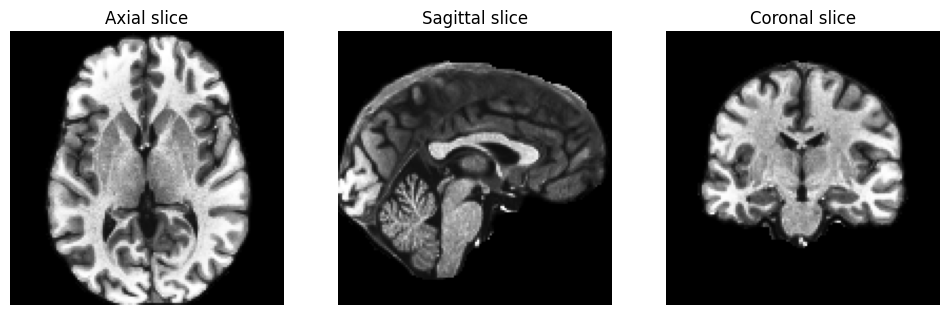

In [ ]:
sample_id = df['subject_id'][0]
nii_path = f'data/{sample_id}/anat/{sample_id}_T1w_processed.nii.gz'

axial, sagittal, coronal = load_middle_slices(nii_path)

# Hiển thị
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(axial.T, cmap='gray', origin='lower')
plt.title('Axial slice')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sagittal.T, cmap='gray', origin='lower')
plt.title('Sagittal slice')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(coronal.T, cmap='gray', origin='lower')
plt.title('Coronal slice')
plt.axis('off')
plt.show()

In [ ]:
class BrainMRIDataset(Dataset):
    def __init__(self, dataframe, root_dir):
        self.df = dataframe
        self.root_dir = root_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        subject_id = row['subject_id']
        age = row['subject_age']
        sex = 0 if row['subject_sex'] == 'm' else 1  # m = 0, f = 1

        nii_path = os.path.join(self.root_dir, subject_id, 'anat', f'{subject_id}_T1w.nii.gz')
        axial, sagittal, coronal = load_middle_slices(nii_path)

        # Stack thành tensor (3, H, W)
        image = np.stack([axial, sagittal, coronal], axis=0).astype(np.float32)

        return {
            'image': torch.tensor(image),
            'age': torch.tensor(age, dtype=torch.float32),
            'sex': torch.tensor(sex, dtype=torch.long),
            'subject_id': subject_id
        }


In [21]:
dataset = BrainMRIDataset(df, 'data_processed')
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

In [22]:
batch = next(iter(dataloader))
print("Image shape:", batch['image'].shape)  # (B, 3, H, W)
print("Age:", batch['age'])
print("Sex:", batch['sex'])
print("Subject IDs:", batch['subject_id'])

FileNotFoundError: No such file or no access: 'data_processed/sub-BrainAge022093/anat/sub-BrainAge022093_T1w_processed.nii.gz'